In [7]:
import h5py
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

## Load IT neuron firing rate

In [2]:
neural_data_pth = '/home/jhanliufu/RutishauserLab/DATA/forJhan/data/MergedITCells_500Stim_AxisTuned.mat'

In [3]:
with h5py.File(neural_data_pth, 'r') as f:
    responses = f['responses']
    # Build full (386 x 500) matrix once
    neural_matrix = np.stack([f[responses[0, i]][()].flatten() for i in range(386)])  # (386, 500)

In [8]:
X = neural_matrix.T  # (500 images, 386 neurons) — cluster images

# --- Normalize: z-score each neuron across images ---
X = StandardScaler().fit_transform(X)  # (500, 386)

# --- PCA for dimensionality reduction before clustering ---
pca = PCA(n_components=50)
X_pca = pca.fit_transform(X)  # (500, 50)
print(f"Variance explained by 50 PCs: {pca.explained_variance_ratio_.sum():.2%}")

Variance explained by 50 PCs: 56.19%


In [9]:
# --- K-Means clustering ---
n_clusters = 6
kmeans = KMeans(n_clusters=n_clusters, n_init=20, random_state=0)
labels = kmeans.fit_predict(X_pca)  # (500,) cluster label per image

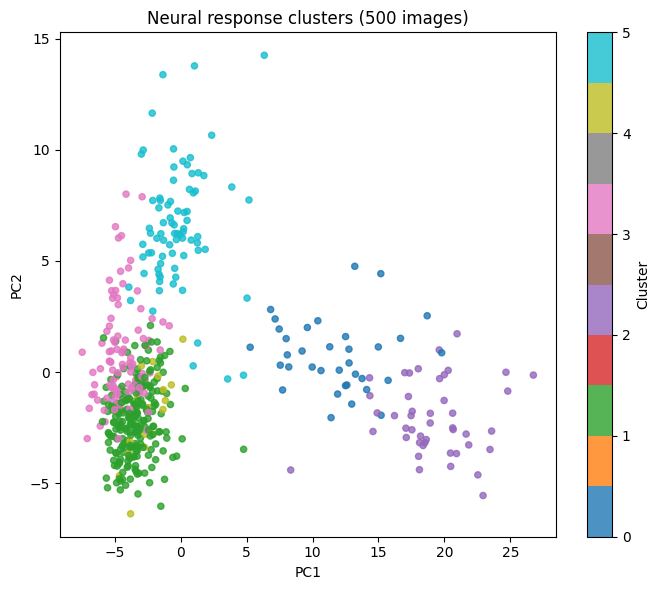

In [10]:
# --- Visualize in 2D PCA space ---
plt.figure(figsize=(7, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10', s=20, alpha=0.8)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('Neural response clusters (500 images)')
plt.tight_layout()